# A mechanism atlas for pointwise intrinsic GAD

## Four small experiments for four distinct design decisions

<div style="padding: 0.9em 1.1em; border-left: 5px solid #0072B2; background: #F3F8FB">
<b>Purpose.</b> The symmetric four-well surface is a useful overview, but it cannot honestly isolate every failure mechanism. This notebook uses a different minimal setup for each question: why GAD works locally, why high-index starts require descent, what gradient competition adds, and why relative soft-subspace reflection is needed near degeneracy.
</div>

The analytic panels explain mechanisms; the LJ7 and g-xTB panels report frozen benchmark evidence from [`POINTWISE_INTRINSIC_GAD.md`](../docs/POINTWISE_INTRINSIC_GAD.md). No toy panel is presented as a chemical benchmark.

## Reading the atlas

| Step | Local question | Isolating experiment |
|---|---|---|
| **1. Ordinary GAD** | Why reflect a mode? | Turn an index-one saddle into a local attractor. |
| **2. Descent-then-GAD** | Why suppress ascent at high index? | Follow matched trajectories into a minimum basin or an index-one corridor. |
| **3. Competitive GAD** | What does force activity add to $\lambda_2$? | Make one finite update choose visibly between a minimum and a saddle. |
| **4. CS²-GAD** | Why use $p_i/\max p$? | Compare a stalled central trajectory with four clear saddle escapes. |

Every section is organized around trajectories on an energy landscape. Step 2 uses the continuous local field to isolate the gate; steps 3–4 use the regularized closed-form update from the final method.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Patch

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 10,
})

COLORS = {
    'descent': '#D55E00', 'ordinary': '#6F6F6F', 'hard': '#CC79A7',
    'lambda2': '#CC79A7', 'competitive': '#0072B2', 'subspace': '#009E73',
}
INDEX_CMAP = ListedColormap(['#EAF4EC', '#FFF3DD', '#F9E5EE'])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60.0, 60.0)))

def normalized_arrows(field, points, length=.10):
    vec = np.asarray([field(p) for p in points], dtype=float)
    norm = np.linalg.norm(vec, axis=1, keepdims=True)
    return length * vec / np.maximum(norm, 1e-12)

def euler_trace(start, field, dt, steps, stop_radius=None):
    path = [np.asarray(start, dtype=float)]
    for _ in range(steps):
        nxt = path[-1] + dt * field(path[-1])
        path.append(nxt)
        if stop_radius is not None and np.linalg.norm(nxt) > stop_radius:
            break
    return np.asarray(path)

def finish_plane(ax, lim, title):
    ax.set(xlim=lim, ylim=lim, aspect='equal', xlabel='$x$', ylabel='$y$', title=title)

# 1. Ordinary GAD makes an index-one saddle attractive

Consider

$$V_1(x,y)=(x^2-1)^2+\tfrac12y^2.$$

The origin is an index-one saddle with $H(0,0)=\operatorname{diag}(-4,1)$. Physical descent is repelled along $x$ and falls into either minimum. Ordinary GAD reflects the lowest-curvature component, so both local directions contract toward the saddle. This is the setting in which one-mode GAD is exactly the right local dynamics.

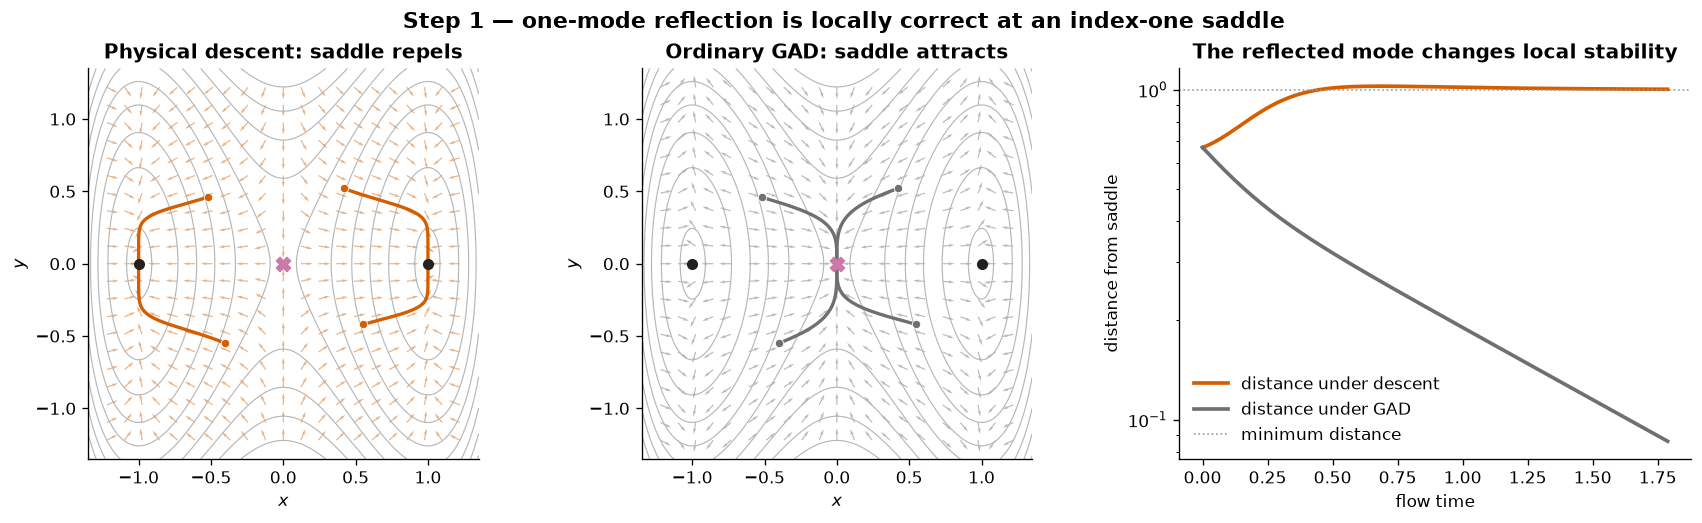

In [2]:
def E1(q):
    x, y = q
    return (x*x - 1.0)**2 + 0.5*y*y

def g1(q):
    x, y = q
    return np.array([4*x*(x*x - 1.0), y])

def H1(q):
    x, _ = q
    return np.diag([12*x*x - 4.0, 1.0])

def ordinary_field(q, grad, hess):
    lam, U = np.linalg.eigh(hess(q))
    c = U.T @ grad(q)
    c[0] *= -1.0
    return U @ (-c)

descent1 = lambda q: -g1(q)
gad1 = lambda q: ordinary_field(q, g1, H1)
starts1 = [(-.52,.46), (-.40,-.55), (.42,.52), (.55,-.42)]
grid1 = np.linspace(-1.35, 1.35, 260)
X1, Y1 = np.meshgrid(grid1, grid1)
Z1 = (X1*X1 - 1.0)**2 + 0.5*Y1*Y1

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.25), constrained_layout=True)
for ax, field, color, title in [
    (axes[0], descent1, COLORS['descent'], 'Physical descent: saddle repels'),
    (axes[1], gad1, COLORS['ordinary'], 'Ordinary GAD: saddle attracts'),
]:
    ax.contour(X1, Y1, Z1, levels=np.linspace(.03, 2.7, 15), colors='#B7B7B7', linewidths=.7)
    gx = np.linspace(-1.22, 1.22, 21); qx, qy = np.meshgrid(gx, gx)
    points = np.column_stack([qx.ravel(), qy.ravel()])
    arrows = normalized_arrows(field, points, .082)
    ax.quiver(points[:,0], points[:,1], arrows[:,0], arrows[:,1], angles='xy', scale_units='xy', scale=1,
              color=color, alpha=.48, width=.003, headwidth=2.6)
    for start in starts1:
        path = euler_trace(start, field, dt=.012, steps=260)
        ax.plot(path[:,0], path[:,1], color=color, lw=2.0)
        ax.scatter(*start, color=color, s=25, edgecolor='white', linewidth=.5, zorder=4)
    ax.scatter([0], [0], marker='X', s=70, color='#CC79A7', zorder=5)
    ax.scatter([-1,1], [0,0], s=32, color='#222222', zorder=5)
    finish_plane(ax, (-1.35,1.35), title)

t = np.arange(150) * .012
example_descent = euler_trace((.42,.52), descent1, .012, 149)
example_gad = euler_trace((.42,.52), gad1, .012, 149)
axes[2].semilogy(t, np.linalg.norm(example_descent, axis=1), color=COLORS['descent'], lw=2.2, label='distance under descent')
axes[2].semilogy(t, np.linalg.norm(example_gad, axis=1), color=COLORS['ordinary'], lw=2.2, label='distance under GAD')
axes[2].axhline(1, color='#999999', ls=':', lw=1, label='minimum distance')
axes[2].set(xlabel='flow time', ylabel='distance from saddle', title='The reflected mode changes local stability')
axes[2].legend(frameon=False)
fig.suptitle('Step 1 — one-mode reflection is locally correct at an index-one saddle', fontsize=13, fontweight='bold')
plt.show()

# 2. Descent-then-GAD avoids the wrong basin

The coupled double well

$$V_2=(x^2-0.25)^2+0.1(y^2-1)^2+0.65x^2y^2$$

has an index-two start region near the origin, minimum basins near $(0,\pm1)$, and index-one saddles near $(\pm0.5,0)$. Ordinary GAD reflects only the most negative mode. The remaining negative mode carries the trajectory upward into the green minimum basin. The smooth $\lambda_2$ gate initially descends in both unstable directions; after the trajectory reaches an index-one corridor, it becomes GAD and approaches the intended saddle. Both trajectories below start at exactly the same point and receive the same update budget.

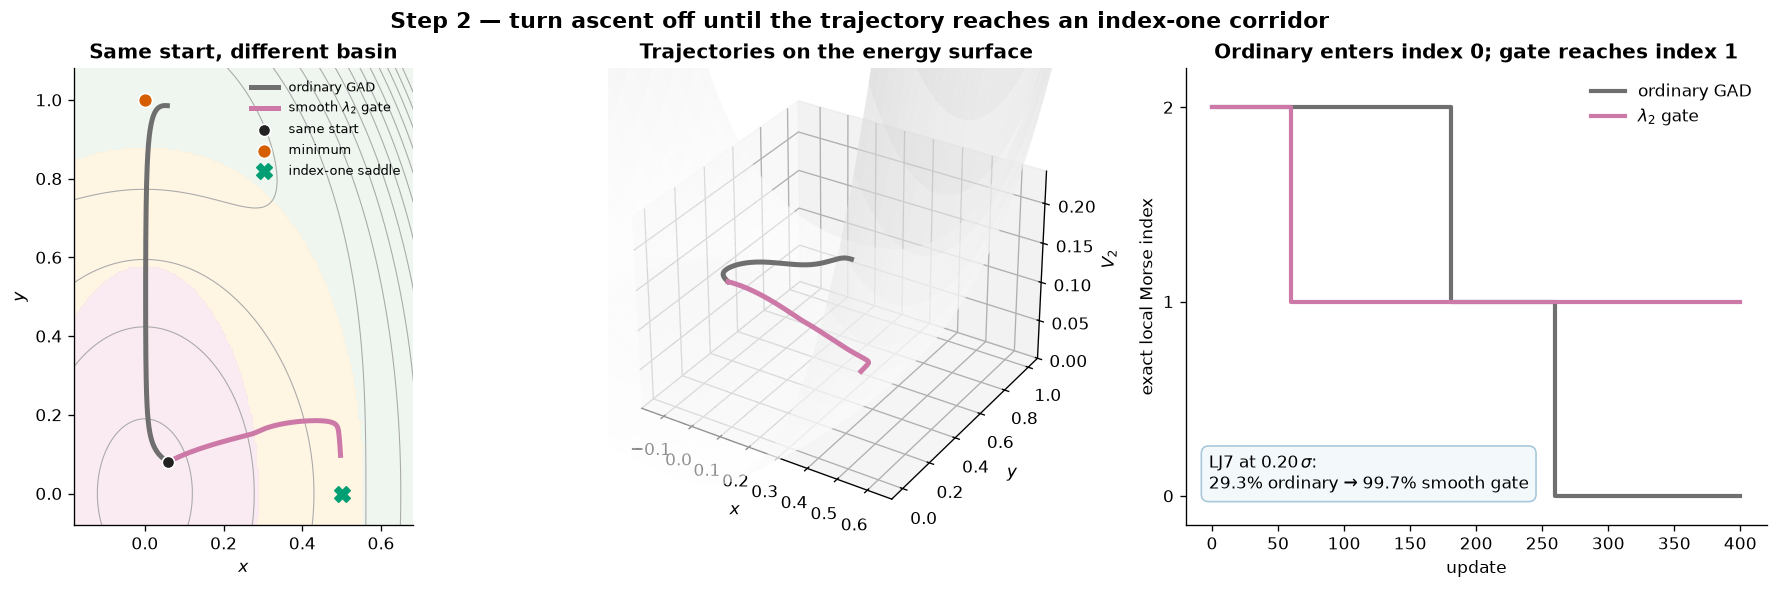

In [3]:
def E2(q):
    x,y=q
    return (x*x-.25)**2+.1*(y*y-1)**2+.65*x*x*y*y

def g2(q):
    x,y=q
    return np.array([4*x*(x*x-.25)+1.3*x*y*y, .4*y*(y*y-1)+1.3*x*x*y])

def H2(q):
    x,y=q
    return np.array([[12*x*x-1+1.3*y*y,2.6*x*y],[2.6*x*y,1.2*y*y-.4+1.3*x*x]])

def field2(q,policy,tau=.12):
    lam,U=np.linalg.eigh(H2(q)); c=U.T@g2(q); sH=max(np.sqrt(np.mean(lam**2)),1e-12)
    w=1.0 if policy=='ordinary' else sigmoid(lam[1]/(tau*sH))
    return U@(-(1-2*w*np.array([1.,0.]))*c)

start2=np.array([.06,.08])
ordinary2=euler_trace(start2,lambda q:field2(q,'ordinary'),.03,400)
gated2=euler_trace(start2,lambda q:field2(q,'lambda2'),.03,400)
grid2=np.linspace(-.72,1.12,330); X2,Y2=np.meshgrid(grid2,grid2)
Z2=(X2*X2-.25)**2+.1*(Y2*Y2-1)**2+.65*X2*X2*Y2*Y2
IDX2=np.empty_like(X2,dtype=int)
for ij in np.ndindex(X2.shape): IDX2[ij]=np.sum(np.linalg.eigvalsh(H2((X2[ij],Y2[ij])))<0)

fig=plt.figure(figsize=(15.2,4.8),constrained_layout=True)
axes=[fig.add_subplot(1,3,1),fig.add_subplot(1,3,2,projection='3d'),fig.add_subplot(1,3,3)]
ax=axes[0]
ax.contourf(X2,Y2,IDX2,levels=[-.5,.5,1.5,2.5],cmap=INDEX_CMAP,alpha=.8)
ax.contour(X2,Y2,Z2,levels=np.linspace(.002,.36,15),colors='#AAAAAA',linewidths=.65)
ax.plot(ordinary2[:,0],ordinary2[:,1],color=COLORS['ordinary'],lw=3,label='ordinary GAD')
ax.plot(gated2[:,0],gated2[:,1],color=COLORS['lambda2'],lw=3,label=r'smooth $\lambda_2$ gate')
ax.scatter(*start2,s=55,color='#222222',edgecolor='white',zorder=5,label='same start')
ax.scatter([0],[1],marker='o',s=70,color='#D55E00',edgecolor='white',zorder=5,label='minimum')
ax.scatter([.5],[0],marker='X',s=85,color='#009E73',zorder=5,label='index-one saddle')
ax.set(xlim=(-.18,.68),ylim=(-.08,1.08),aspect='equal',xlabel='$x$',ylabel='$y$',title='Same start, different basin')
ax.legend(frameon=False,fontsize=8,loc='upper right')

ax=axes[1]; stride=7
ax.plot_surface(X2[::stride,::stride],Y2[::stride,::stride],Z2[::stride,::stride],cmap='Greys',alpha=.58,linewidth=0)
for path,color in [(ordinary2,COLORS['ordinary']),(gated2,COLORS['lambda2'])]:
    ax.plot(path[:,0],path[:,1],[E2(q)+.008 for q in path],color=color,lw=3,zorder=10)
ax.set(xlim=(-.18,.68),ylim=(-.08,1.08),zlim=(0,.24),xlabel='$x$',ylabel='$y$',zlabel='$V_2$',title='Trajectories on the energy surface')
ax.view_init(31,-58)

index_ord=[np.sum(np.linalg.eigvalsh(H2(q))<0) for q in ordinary2]
index_gate=[np.sum(np.linalg.eigvalsh(H2(q))<0) for q in gated2]
axes[2].step(range(len(index_ord)),index_ord,where='post',color=COLORS['ordinary'],lw=2.5,label='ordinary GAD')
axes[2].step(range(len(index_gate)),index_gate,where='post',color=COLORS['lambda2'],lw=2.5,label=r'$\lambda_2$ gate')
axes[2].set(xlabel='update',ylabel='exact local Morse index',yticks=[0,1,2],ylim=(-.15,2.2),title='Ordinary enters index 0; gate reaches index 1')
axes[2].legend(frameon=False)
axes[2].text(.04,.08,'LJ7 at $0.20\,\sigma$:\n29.3% ordinary → 99.7% smooth gate',transform=axes[2].transAxes,
             bbox=dict(boxstyle='round,pad=.45',fc='#F3F8FB',ec='#A8C9DB'))
fig.suptitle('Step 2 — turn ascent off until the trajectory reaches an index-one corridor',fontsize=13,fontweight='bold')
plt.show()

# 3. Competitive GAD prevents a finite-step minimum capture

This surface places a very narrow index-two strip between an index-one saddle at $(0,0)$ and a minimum at $(0.6,0)$:

$$V_3=(x^2-0.36)^2+\tfrac12k(x)y^2+4y^4,$$
$$k(x)=1-1.2\exp[-((x-0.30)/0.055)^2].$$

At the black start, both curvatures are negative but essentially all force activity lies in the soft $x$ mode. The curvature-only gate therefore takes a descent step across the thin index-one strip and lands in the minimum basin. Competitive GAD sees the concentrated activity and reverses the same component immediately, reaching the saddle in two updates. This intentionally magnifies the finite-step capture mechanism observed in the molecular runs.

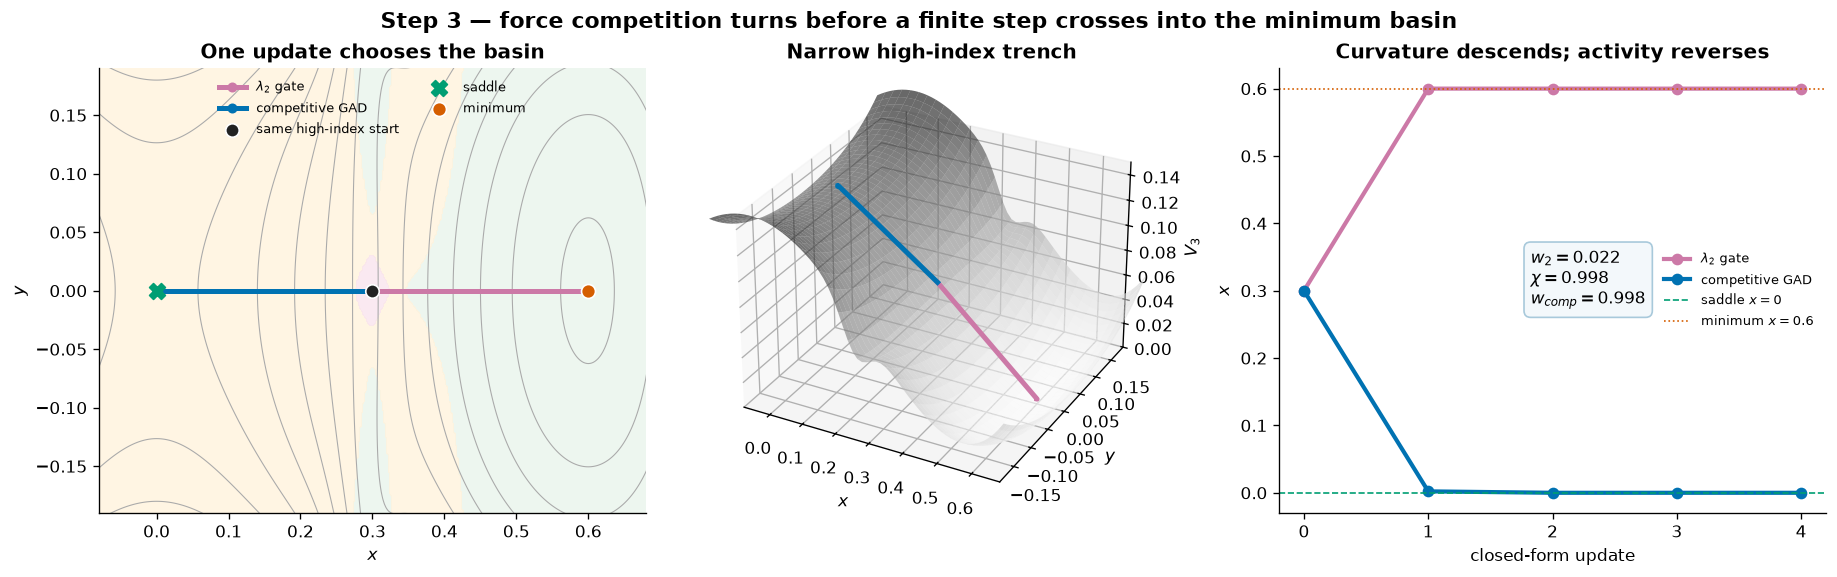

In [4]:
A3=.6; XC3=.30; WIDTH3=.055
def k3(x): return 1-1.2*np.exp(-((x-XC3)/WIDTH3)**2)
def kp3(x): return 2.4*(x-XC3)/WIDTH3**2*np.exp(-((x-XC3)/WIDTH3)**2)
def kpp3(x): return 2.4/WIDTH3**2*np.exp(-((x-XC3)/WIDTH3)**2)*(1-2*(x-XC3)**2/WIDTH3**2)
def E3(q):
    x,y=q; return (x*x-A3*A3)**2+.5*k3(x)*y*y+4*y**4
def g3(q):
    x,y=q; return np.array([4*x*(x*x-A3*A3)+.5*kp3(x)*y*y,k3(x)*y+16*y**3])
def H3(q):
    x,y=q; return np.array([[12*x*x-4*A3*A3+.5*kpp3(x)*y*y,kp3(x)*y],[kp3(x)*y,k3(x)+48*y*y]])

def step3(q,competitive=False,tau=.18,R=.32):
    lam,U=np.linalg.eigh(H3(q)); c=U.T@g3(q); sH=max(np.sqrt(np.mean(lam**2)),1e-12)
    z=lam/(tau*sH); p=np.exp(-z-np.max(-z)); p/=p.sum(); neg=sigmoid(-z); w2=sigmoid(z[1])
    Asoft=np.sum(p*c*c); Aextra=np.sum(neg*(1-p)**2*c*c)
    chi=Asoft/(Asoft+Aextra) if Asoft+Aextra>0 else 0.0
    w=w2+(1-w2)*chi if competitive else w2
    b=(1-2*w*p)*c; mu=np.linalg.norm(b)/R if np.linalg.norm(b)>0 else 0.0
    return U@(-b/np.sqrt(lam*lam+mu*mu)),dict(w2=w2,chi=chi,w=w,lam=lam)

def trace3(competitive,steps=14):
    path=[np.array([.30,0.])]; diag=[]
    for _ in range(steps):
        dq,d=step3(path[-1],competitive); diag.append(d); path.append(path[-1]+dq)
    return np.asarray(path),diag
lambda3,diag_lambda3=trace3(False); comp3,diag_comp3=trace3(True)
gridx3=np.linspace(-.12,.72,380); gridy3=np.linspace(-.22,.22,250); X3,Y3=np.meshgrid(gridx3,gridy3)
Z3=(X3*X3-A3*A3)**2+.5*(1-1.2*np.exp(-((X3-XC3)/WIDTH3)**2))*Y3*Y3+4*Y3**4
IDX3=np.empty_like(X3,dtype=int)
for ij in np.ndindex(X3.shape): IDX3[ij]=np.sum(np.linalg.eigvalsh(H3((X3[ij],Y3[ij])))<0)

fig=plt.figure(figsize=(15.2,4.7),constrained_layout=True)
axes=[fig.add_subplot(1,3,1),fig.add_subplot(1,3,2,projection='3d'),fig.add_subplot(1,3,3)]
ax=axes[0]
ax.contourf(X3,Y3,IDX3,levels=[-.5,.5,1.5,2.5],cmap=INDEX_CMAP,alpha=.82)
ax.contour(X3,Y3,Z3,levels=np.linspace(.002,.15,14),colors='#AAAAAA',linewidths=.65)
ax.plot(lambda3[:,0],lambda3[:,1],'-o',markevery=[0,1,2],color=COLORS['lambda2'],lw=3,ms=5,label=r'$\lambda_2$ gate')
ax.plot(comp3[:,0],comp3[:,1],'-o',markevery=[0,1,2],color=COLORS['competitive'],lw=3,ms=5,label='competitive GAD')
ax.scatter([.30],[0],s=65,color='#222222',edgecolor='white',zorder=6,label='same high-index start')
ax.scatter([0],[0],marker='X',s=90,color='#009E73',zorder=6,label='saddle')
ax.scatter([.6],[0],s=70,color='#D55E00',edgecolor='white',zorder=6,label='minimum')
ax.set(xlim=(-.08,.68),ylim=(-.19,.19),xlabel='$x$',ylabel='$y$',title='One update chooses the basin')
ax.legend(frameon=False,fontsize=8,loc='upper center',ncol=2)

ax=axes[1]; stride=6
ax.plot_surface(X3[::stride,::stride],Y3[::stride,::stride],Z3[::stride,::stride],cmap='Greys',alpha=.6,linewidth=0)
for path,color in [(lambda3,COLORS['lambda2']),(comp3,COLORS['competitive'])]:
    ax.plot(path[:,0],path[:,1],[E3(q)+.004 for q in path],color=color,lw=3,zorder=10)
ax.set(xlim=(-.08,.68),ylim=(-.19,.19),zlim=(0,.15),xlabel='$x$',ylabel='$y$',zlabel='$V_3$',title='Narrow high-index trench')
ax.view_init(29,-62)

nshow=5
axes[2].plot(range(nshow),lambda3[:nshow,0],'-o',color=COLORS['lambda2'],lw=2.5,label=r'$\lambda_2$ gate')
axes[2].plot(range(nshow),comp3[:nshow,0],'-o',color=COLORS['competitive'],lw=2.5,label='competitive GAD')
axes[2].axhline(0,color='#009E73',ls='--',lw=1,label='saddle $x=0$')
axes[2].axhline(.6,color='#D55E00',ls=':',lw=1,label='minimum $x=0.6$')
axes[2].set(xlabel='closed-form update',ylabel='$x$',xticks=range(nshow),title='Curvature descends; activity reverses')
axes[2].legend(frameon=False,fontsize=8)
d0=diag_comp3[0]
axes[2].text(.46,.47,fr'$w_2={d0["w2"]:.3f}$'+'\n'+fr'$\chi={d0["chi"]:.3f}$'+'\n'+fr'$w_{{comp}}={d0["w"]:.3f}$',
             transform=axes[2].transAxes,bbox=dict(boxstyle='round,pad=.4',fc='#F3F8FB',ec='#A8C9DB'))
fig.suptitle('Step 3 — force competition turns before a finite step crosses into the minimum basin',fontsize=13,fontweight='bold')
plt.show()

The black point is identical in both runs. Its curvature-only gate is almost off, $w_2\approx0$, so the magenta step follows descent to the right. The competitive activity is almost one, so the blue step reflects the soft component and moves left. The index-one strip is deliberately thinner than the intrinsic display radius: this is a visual stress test of the exact finite-step failure, not a claim that chemical landscapes have this particular shape.

# 4. Relative soft-subspace reflection prevents degeneracy dilution

Use an isotropic central basin surrounded by four discrete index-one saddles:

$$s=x^2+y^2,$$
$$V_4=\tfrac12s-\tfrac34s^2+\tfrac16s^3+\epsilon(x^4-6x^2y^2+y^4),\qquad \epsilon=0.03.$$

Near the central minimum, $H\approx I$ and $p_1\approx p_2\approx1/2$. With an active gate, normalized-density reflection gives $1-2wp_i\approx0$: it nearly cancels the local field. CS²-GAD instead uses $\widetilde p_i=p_i/\max_jp_j$, giving unit weight to the tied lowest subspace and a full, rotation-invariant reversal. The start must be slightly displaced because every force-proportional pointwise method has zero step at an exact stationary minimum.

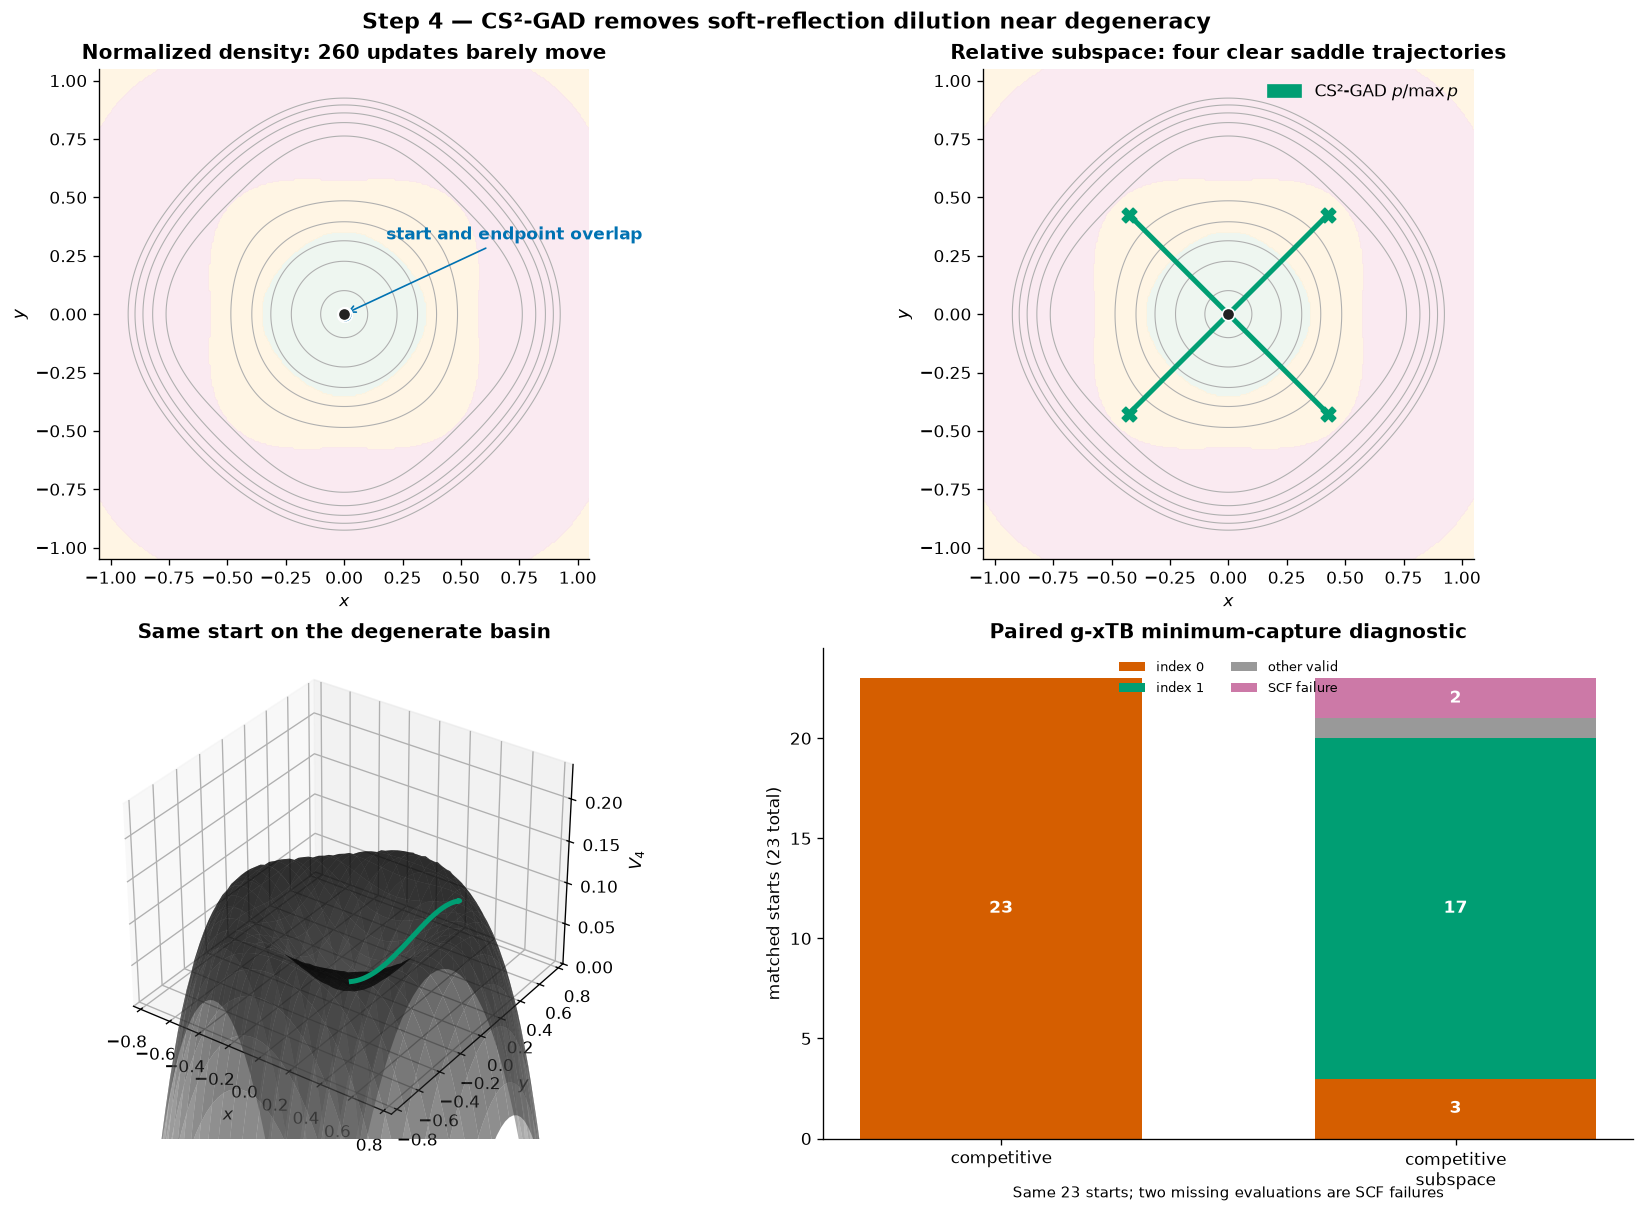

In [5]:
EPS4=.03
def E4(q):
    x,y=q; s=x*x+y*y
    return .5*s-.75*s*s+s**3/6 + EPS4*(x**4-6*x*x*y*y+y**4)

def g4(q):
    x,y=q; s=x*x+y*y
    radial=(1-3*s+s*s)*np.array([x,y])
    anis=EPS4*np.array([4*x**3-12*x*y*y,4*y**3-12*x*x*y])
    return radial+anis

def H4(q):
    x,y=q; s=x*x+y*y; v=np.array([x,y])
    H=(1-3*s+s*s)*np.eye(2)+4*(-1.5+s)*np.outer(v,v)
    H+=EPS4*np.array([[12*x*x-12*y*y,-24*x*y],[-24*x*y,12*y*y-12*x*x]])
    return H

def soft_step4(q, relative=False, tau=.18, R=.018):
    lam,U=np.linalg.eigh(H4(q)); c=U.T@g4(q); sH=max(np.sqrt(np.mean(lam**2)),1e-12)
    z=lam/(tau*sH); p=np.exp(-z-np.max(-z)); p/=p.sum()
    neg=sigmoid(-z); w2=sigmoid(z[1])
    Asoft=np.sum(p*c*c); Aextra=np.sum(neg*(1-p)**2*c*c)
    chi=Asoft/(Asoft+Aextra) if Asoft+Aextra>0 else 0.0
    w=w2+(1-w2)*chi; r=p/p.max() if relative else p
    b=(1-2*w*r)*c; mu=np.linalg.norm(b)/R if np.linalg.norm(b)>0 else 0.0
    step=U@(-b/np.sqrt(lam*lam+mu*mu))
    return step,dict(lam=lam,p=p,w=w,r=r,multiplier=1-2*w*r)

def trace4(start,relative,steps=260):
    path=[np.asarray(start,dtype=float)]; diagnostics=[]
    for _ in range(steps):
        dq,diag=soft_step4(path[-1],relative=relative); diagnostics.append(diag)
        path.append(path[-1]+dq)
    return np.asarray(path),diagnostics

angles=np.pi/4+np.arange(4)*np.pi/2
starts4=[.003*np.array([np.cos(a),np.sin(a)]) for a in angles]
density_paths=[trace4(s,False)[0] for s in starts4]
relative_paths=[trace4(s,True)[0] for s in starts4]

grid4=np.linspace(-1.05,1.05,360); X4,Y4=np.meshgrid(grid4,grid4)
S4=X4*X4+Y4*Y4
Z4=.5*S4-.75*S4**2+S4**3/6+EPS4*(X4**4-6*X4*X4*Y4*Y4+Y4**4)
idx4=np.empty_like(X4,dtype=int)
for ij in np.ndindex(X4.shape):
    idx4[ij]=np.sum(np.linalg.eigvalsh(H4((X4[ij],Y4[ij])))<0)

fig=plt.figure(figsize=(14.2,10.0),constrained_layout=True)
axes=[fig.add_subplot(2,2,1),fig.add_subplot(2,2,2),fig.add_subplot(2,2,3,projection='3d'),fig.add_subplot(2,2,4)]
for ax,title in [(axes[0],'Normalized density: 260 updates barely move'),(axes[1],'Relative subspace: four clear saddle trajectories')]:
    ax.contourf(X4,Y4,idx4,levels=[-.5,.5,1.5,2.5],cmap=INDEX_CMAP,alpha=.78)
    ax.contour(X4,Y4,Z4,levels=np.linspace(.005,.23,13),colors='#AFAFAF',linewidths=.65)
    finish_plane(ax,(-1.05,1.05),title)
for path in density_paths:
    axes[0].plot(path[:,0],path[:,1],color=COLORS['competitive'],lw=3)
    axes[0].scatter(*path[-1],s=65,color=COLORS['competitive'],edgecolor='white',zorder=6)
for path in relative_paths:
    axes[1].plot(path[:,0],path[:,1],color=COLORS['subspace'],lw=3)
    axes[1].scatter(*path[-1],marker='X',s=75,color=COLORS['subspace'],zorder=6)
for ax in axes[:2]:
    ax.scatter([0],[0],s=55,color='#222222',edgecolor='white',zorder=7,label='near-degenerate minimum')
axes[0].annotate('start and endpoint overlap',xy=(0,0),xytext=(.18,.32),arrowprops=dict(arrowstyle='->',color=COLORS['competitive']),color=COLORS['competitive'],fontweight='bold')
axes[1].legend(handles=[Patch(color=COLORS['subspace'],label=r'CS²-GAD $p/\max p$')],frameon=False,loc='upper right')

ax=axes[2]; stride=7
ax.plot_surface(X4[::stride,::stride],Y4[::stride,::stride],Z4[::stride,::stride],cmap='Greys',alpha=.58,linewidth=0)
for path,color in [(density_paths[0],COLORS['competitive']),(relative_paths[0],COLORS['subspace'])]:
    ax.plot(path[:,0],path[:,1],[E4(q)+.004 for q in path],color=color,lw=3,zorder=10)
ax.set(xlim=(-.85,.85),ylim=(-.85,.85),zlim=(0,.24),xlabel='$x$',ylabel='$y$',zlabel='$V_4$',title='Same start on the degenerate basin')
ax.view_init(32,-55)

categories=['index 0','index 1','other valid','SCF failure']
baseline=np.array([23,0,0,0]); refined=np.array([3,17,1,2])
cat_colors=['#D55E00','#009E73','#999999','#CC79A7']
bottom=np.zeros(2)
for i,(cat,color) in enumerate(zip(categories,cat_colors)):
    vals=np.array([baseline[i],refined[i]])
    axes[3].bar(['competitive','competitive\nsubspace'],vals,bottom=bottom,color=color,label=cat,width=.62)
    for j,val in enumerate(vals):
        if val>=2: axes[3].text(j,bottom[j]+val/2,str(val),ha='center',va='center',color='white',fontweight='bold')
    bottom+=vals
axes[3].set(ylim=(0,24.5),ylabel='matched starts (23 total)',title='Paired g-xTB minimum-capture diagnostic')
axes[3].legend(frameon=False,ncol=2,loc='upper center',fontsize=8)
axes[3].text(.5,-.12,'Same 23 starts; two missing evaluations are SCF failures',transform=axes[3].transAxes,ha='center',fontsize=9)
fig.suptitle('Step 4 — CS²-GAD removes soft-reflection dilution near degeneracy',fontsize=13,fontweight='bold')
plt.show()

## What the degeneracy experiment does—and does not—claim

The relevant failure is **reflection dilution**, not merely a small eigenvalue. A tilted sombrero has a soft tangent mode but normally a large gap to its radial mode; that is not the degeneracy addressed here. In the constructed basin, two comparably soft modes receive $p_i\approx1/2$, so the intermediate normalized rule nearly cancels descent instead of producing ascent. Relative weights act on the low-curvature subspace without choosing an arbitrary eigenvector.

The toy deliberately shows the local escape mechanism. The stacked bar is the evidence that this mechanism mattered on matched molecular starts: 20 of 23 original minimum captures were prevented, while two refined calculations failed in g-xTB rather than reaching optimizer terminals.

# Takeaway

<div style="padding: 0.9em 1.1em; border-left: 5px solid #009E73; background: #F3FBF7">
<b>The four additions solve different local problems.</b> Ordinary GAD stabilizes an index-one saddle. The $\lambda_2$ gate prevents unreflected high-index modes from dominating entry. Competition uses current force activity to begin a justified soft escape before curvature alone permits it. Relative soft-subspace reflection prevents that escape from being diluted when several lowest modes are comparable.
</div>

These panels should be read alongside the compact [`gad_evolution_four_wells.ipynb`](gad_evolution_four_wells.ipynb) overview and the complete derivation in [`POINTWISE_INTRINSIC_GAD.md`](../docs/POINTWISE_INTRINSIC_GAD.md).